# Random Forest Classifier

In this notebook I use a Random Forest classifier to predict whether Player 1 wins a tennis match.

The model is trained on the same training set used for the ANN and evaluated on the 2023 validation set.

Different Random Forest configurations are tested in order to fine-tune the model parameters.

In [8]:
from pathlib import Path 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    log_loss, 
    confusion_matrix, 
    classification_report
)

In [9]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = ( PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(
    input_file, parse_dates=["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)

print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [10]:
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

print( 
    "Training:", 
    train_data["Date"].min(), 
    "-", 
    train_data["Date"].max()
)

print(
    "Validation:", 
    validation_data["Date"].min(),
    "-", 
    validation_data["Date"].max()
)

print(
    "Test:", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [11]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw selected features:",
    len(numeric_features)
    + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


In [12]:
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


In [13]:
print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)
print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "Random Forest preprocessing check passed."
)

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
Random Forest preprocessing check passed.


Unlike the ANN, I do not standardize the features for the Random Forest.

A Random Forest makes decisions by comparing individual feature values
with thresholds. Therefore, a feature measured on a larger numerical
scale does not automatically dominate the model in the same way it
could in a distance-based model or a neural network.

The one-hot encoded categorical features can therefore remain 0/1,
while the numerical features remain on their original scales.

In [14]:
model = RandomForestClassifier(
    n_estimators = 100, 
    max_depth = None, 
    min_samples_leaf=1, 
    max_features="sqrt",
    
    # makes the result reproducible
    random_state=42, 
    
    n_jobs=-1 #This tells scikit-learn to use all available processor cores when possible.
    #It changes speed, not the mathematical model.
)

In [15]:
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [16]:
validation_predictions = model.predict(X_validation)

In [17]:
validation_probabilities = (
    model.predict_proba(X_validation)[:, 1]
)

In [18]:
initial_results = pd.DataFrame(
    {
        "Model": ["Initial Random Forest"], 
        "Accuracy": [
            accuracy_score(
                y_validation, 
                validation_predictions
            )
        ],
        "BalancedAccuracy": [
            balanced_accuracy_score(
                y_validation, 
                validation_predictions
            )
        ], 
        "Precision": [
            precision_score(
                y_validation, 
                validation_predictions, 
                zero_division=0
            )
        ], 
        "Recall": [
            recall_score(
                y_validation, 
                validation_predictions,
                zero_division=0
            )
        ], 
        "F1": [
            f1_score(
                y_validation, 
                validation_predictions, 
                zero_division=0
            )
        ], 
        "ROC_AUC" : [
            roc_auc_score(
                y_validation, 
                validation_probabilities
            )
        ], 
        "LogLoss": [
            log_loss(
                y_validation, 
                validation_probabilities
            )
        ]  
        
    }
)

initial_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Initial Random Forest,0.628692,0.628466,0.606275,0.62389,0.614956,0.688237,0.633442


In [19]:
print(
    classification_report(
        y_validation, 
        validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.65      0.63      0.64      1368
Player 1 wins       0.61      0.62      0.61      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.63      0.63      2607
 weighted avg       0.63      0.63      0.63      2607



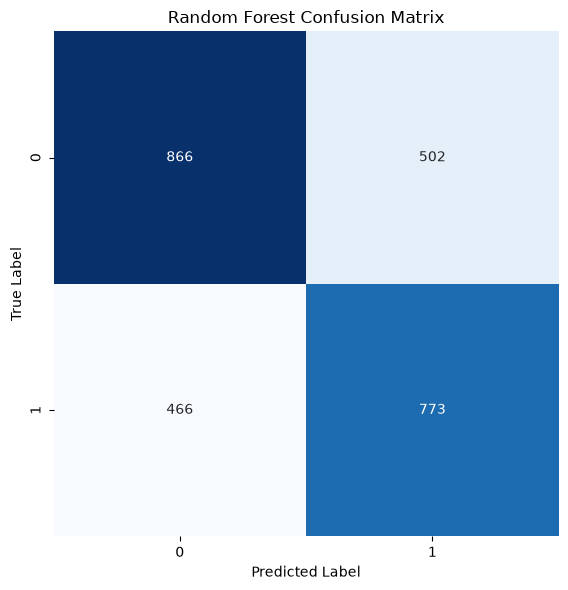

In [20]:
matrix = confusion_matrix(
    y_validation, 
    validation_predictions
)

fig, axes = plt.subplots(
    figsize=(6, 6), 
    tight_layout=True
)

sns.heatmap(
    matrix, 
    square=True, 
    annot=True, 
    fmt="d", 
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")
axes.set_ylabel("True Label")
axes.set_title("Random Forest Confusion Matrix")
plt.show()

In [21]:
configurations = [
    {
        "name": "RF 100", 
        "n_estimators": 100, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200", 
        "n_estimators": 200, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 10", 
        "n_estimators": 200, 
        "max_depth": 10, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 15", 
        "n_estimators": 200, 
        "max_depth": 15, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 300 depth 10 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 10, 
        "min_samples_leaf": 2
    },
    {
        "name": "RF 300 depth 15 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 15, 
        "min_samples_leaf": 2
    }
]

In [22]:
# train every configuration 
tuning_results = []
trained_models = {}

for configuration in configurations:
    
    print("\nTraining:", configuration["name"])
    
    current_model = RandomForestClassifier(
        n_estimators= configuration["n_estimators"],
        max_depth= configuration["max_depth"], 
        min_samples_leaf= configuration["min_samples_leaf"],
        max_features="sqrt", 
        random_state=42, 
        n_jobs=-1
    )
    
    current_model.fit(X_train, y_train)
    
    current_predictions = (
        current_model.predict(X_validation)
    )
    
    current_probabilities = (
        current_model.predict_proba(X_validation)[:, 1]
    )
    
    current_accuracy = accuracy_score(
        y_validation, 
        current_predictions
    )
    
    current_balanced_accuracy = balanced_accuracy_score(
        y_validation, 
        current_predictions
    )
    
    current_precision = precision_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_recall = recall_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_f1 = f1_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_roc_auc = roc_auc_score(
        y_validation, 
        current_probabilities
    )
    
    current_log_loss = log_loss(
        y_validation, 
        current_probabilities
    )
    
    tuning_results.append(
        {
            "Model": configuration["name"], 
            "NumberOfTrees": configuration["n_estimators"], 
            "MaxDepth": configuration["max_depth"], 
            "MinSamplesLeaf": configuration["min_samples_leaf"], 
            "Accuracy": current_accuracy, 
            "BalancedAccuracy": current_balanced_accuracy, 
            "Precision": current_precision, 
            "Recall": current_recall, 
            "F1": current_f1, 
            "ROC_AUC": current_roc_auc, 
            "LogLoss": current_log_loss
        }
    )
    
    trained_models[configuration["name"]] = current_model
    
    print("Validation accuracy:", round(current_accuracy, 4))
    


Training: RF 100
Validation accuracy: 0.6287

Training: RF 200
Validation accuracy: 0.631

Training: RF 200 depth 10
Validation accuracy: 0.6414

Training: RF 200 depth 15
Validation accuracy: 0.6318

Training: RF 300 depth 10 leaf 2
Validation accuracy: 0.6394

Training: RF 300 depth 15 leaf 2
Validation accuracy: 0.6417


In [23]:
tuning_results = pd.DataFrame(tuning_results)

tuning_results = (
    tuning_results.sort_values(
        by=["Accuracy", "ROC_AUC"], 
        ascending=[False, False]
    ).reset_index(drop=True)
)

tuning_results

,Model,NumberOfTrees,MaxDepth,MinSamplesLeaf,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,RF 300 depth 15 leaf 2,300,15.0,2,0.641734,0.641920,0.617761,0.645682,0.631413,0.701174,0.625666
1,RF 200 depth 10,200,10.0,1,0.641350,0.641174,0.619122,0.637611,0.628231,0.703815,0.624294
2,RF 300 depth 10 leaf 2,300,10.0,2,0.639432,0.639613,0.615444,0.643261,0.629045,0.704550,0.624086
3,RF 200 depth 15,200,15.0,1,0.631761,0.631846,0.608056,0.633575,0.620553,0.696549,0.628092
4,RF 200,200,NaN,1,0.630993,0.631077,0.607281,0.632768,0.619763,0.692224,0.631379
5,RF 100,100,NaN,1,0.628692,0.628466,0.606275,0.623890,0.614956,0.688237,0.633442


In [24]:
best_model_name = (tuning_results.iloc[0]["Model"])
best_model = trained_models[best_model_name]
print("Selected Random Forest:", best_model_name)

Selected Random Forest: RF 300 depth 15 leaf 2


In [25]:
best_validation_predictions = (
    best_model.predict(X_validation)
)

best_validation_probabilities = (
    best_model.predict_proba(X_validation)[:, 1]
)

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.67      0.64      0.65      1368
Player 1 wins       0.62      0.65      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [26]:
# Random Forest assigns an importance value
# to every input feature used by the model.
#
# X_train.columns contains the exact 50 input feature names,
# including both:
#
# - numerical features
# - one-hot encoded categorical features

feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_ #assigns an importance value to each input feature.
        #The values add approximately to 1
    }
)

# Order the features from most important to least important.
feature_importance = (
    feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)
feature_importance

,Feature,Importance
0,PointsDifference,0.088695
1,RankDifference,0.069594
2,WinRateDifference,0.064975
3,SurfaceWinRateDifference,0.054856
4,Player1Points,0.046230
5,Player2Points,0.045949
6,Player1Rank,0.041825
7,SurfaceMatchesDifference,0.040688
8,ExperienceDifference,0.040654
9,Player2Rank,0.040397


In [27]:
print("Number of model features:", X_train.shape[1])
print("Number of feature importances:", len(best_model.feature_importances_))

assert(len(feature_importance) == X_train.shape[1])
print("Feature importance check passed.")

Number of model features: 50
Number of feature importances: 50
Feature importance check passed.


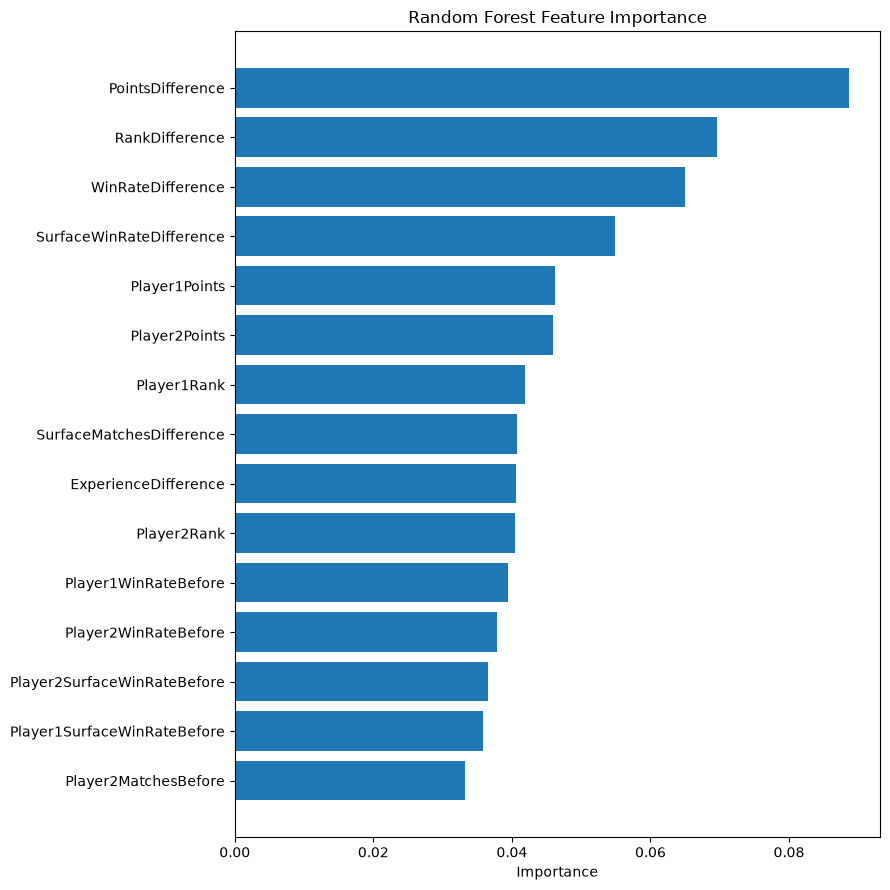

In [28]:
top_features = (
    feature_importance.head(15).sort_values(
        by="Importance", ascending=True
    )
)

plt.figure(figsize=(9, 9))
plt.barh(
    top_features["Feature"], 
    top_features["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Feature importance

The feature importance values will be analysed after selecting
the best Random Forest configuration.

This analysis allows me to investigate whether the newly engineered
historical features and the categorical match information contribute
to the predictions.

In [29]:
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

tuning_results.to_csv(
    RESULTS_DIR / "RF_tuning_results.csv", index=False
)

feature_importance.to_csv(
    RESULTS_DIR / "RF_feature_importance.csv", index=False
)


In [30]:
import joblib 

joblib.dump(best_model, MODELS_DIR / "best_RF_validation.joblib")

['..\\models\\best_RF_validation.joblib']

In [31]:
# final tuning summary 
print(
    tuning_results[
        [
            "Model",
            "NumberOfTrees",
            "MaxDepth",
            "MinSamplesLeaf",
            "Accuracy",
            "BalancedAccuracy",
            "F1",
            "ROC_AUC",
            "LogLoss"
        ]
    ]
)

                    Model  NumberOfTrees  MaxDepth  MinSamplesLeaf  Accuracy  \
0  RF 300 depth 15 leaf 2            300      15.0               2  0.641734   
1         RF 200 depth 10            200      10.0               1  0.641350   
2  RF 300 depth 10 leaf 2            300      10.0               2  0.639432   
3         RF 200 depth 15            200      15.0               1  0.631761   
4                  RF 200            200       NaN               1  0.630993   
5                  RF 100            100       NaN               1  0.628692   

   BalancedAccuracy        F1   ROC_AUC   LogLoss  
0          0.641920  0.631413  0.701174  0.625666  
1          0.641174  0.628231  0.703815  0.624294  
2          0.639613  0.629045  0.704550  0.624086  
3          0.631846  0.620553  0.696549  0.628092  
4          0.631077  0.619763  0.692224  0.631379  
5          0.628466  0.614956  0.688237  0.633442  


In [32]:
print(feature_importance.head(15))

                        Feature  Importance
0              PointsDifference    0.088695
1                RankDifference    0.069594
2             WinRateDifference    0.064975
3      SurfaceWinRateDifference    0.054856
4                 Player1Points    0.046230
5                 Player2Points    0.045949
6                   Player1Rank    0.041825
7      SurfaceMatchesDifference    0.040688
8          ExperienceDifference    0.040654
9                   Player2Rank    0.040397
10         Player1WinRateBefore    0.039501
11         Player2WinRateBefore    0.037876
12  Player2SurfaceWinRateBefore    0.036520
13  Player1SurfaceWinRateBefore    0.035778
14         Player2MatchesBefore    0.033225
